# MS gate simulation / QPT analysis

レーザー揺らぎなしの基準データを計算し、post-gate error channel の chi を解析。


MS gate simulation progress: 1 n_bar values x 1 laser samples x 16 input states = 16 evolutions (16 evolutions / n_bar)
n_bar = 0.01 Simulation Finished (Dim: 20)


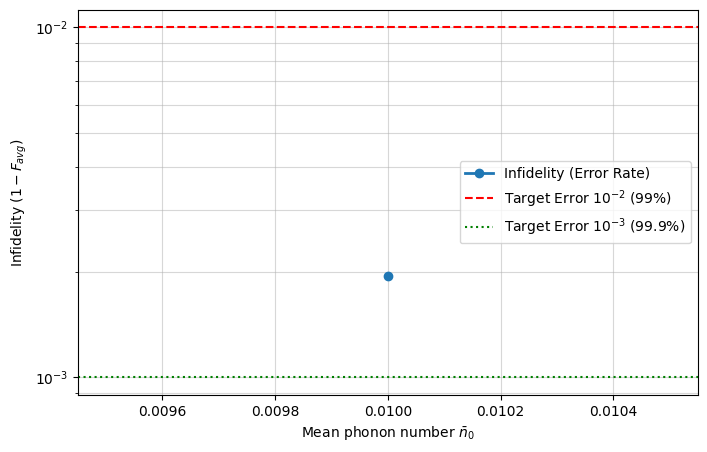

--- Result Summary (Error Rate) ---
n_bar = 0.01: Error = 1.946492e-03 (Fidelity = 0.998054)


In [4]:
# Infidelity を生成するセル
import importlib
import numpy as np
import pandas as pd
import ms_gate_functions as mg
import stim_pauli_noise as spn

mg = importlib.reload(mg)
spn = importlib.reload(spn)

# --- MS gate parameters ---
A = 0.125
delta = 0.5
rho0 = 0.0
n_bar_list = np.r_[0.01]
time_points = 500
t_gate_phys = 100e-6
eta = 0.1


# --- Decoherence / scattering rates in physical time ---
heating_rate_phys = 10.0
dephasing_rate_phys = 18.0
T2_star = 0.3
rayleigh_rate_phys = 3.0
raman_rate_phys = 1.0

# --- Static / quasi-static laser noise ---
laser_intensity_fluctuation = 0#0.015  # fractional RMS of A
laser_detuning_fluctuation_phys = 0#2 * np.pi * 0.3e3  # rad/s RMS
t_gate_sim = 2 * np.pi / delta
laser_detuning_fluctuation = laser_detuning_fluctuation_phys * t_gate_phys / t_gate_sim
laser_rotation_angle_fluctuation = 0#0.1  # rad RMS
laser_noise_samples = 1
laser_noise_seed = 1234

simulation_params = {
    "A": A,
    "delta": delta,
    "rho0": rho0,
    "n_bar_list": n_bar_list,
    "time_points": time_points,
    "t_gate_phys": t_gate_phys,
    "heating_rate_phys": heating_rate_phys,
    "dephasing_rate_phys": dephasing_rate_phys,
    "T2_star": T2_star,
    "rayleigh_rate_phys": rayleigh_rate_phys,
    "raman_rate_phys": raman_rate_phys,
    "eta": eta,
    "laser_intensity_fluctuation": laser_intensity_fluctuation,
    "laser_detuning_fluctuation": laser_detuning_fluctuation,
    "laser_rotation_angle_fluctuation": laser_rotation_angle_fluctuation,
    "laser_noise_samples": laser_noise_samples,
    "laser_noise_seed": laser_noise_seed,
    "use_full_order": True,
    "show_progress": True,
}

infidelity_result = mg.run_infidelity_analysis(
    **simulation_params,
    show_plot=True,
)
infidelity_list = infidelity_result["infidelity_list"]
f_avg_list = infidelity_result["f_avg_list"]

MS gate simulation (16 evolutions / n_bar):   0%|          | 0/80 [00:00<?, ?evolution/s]

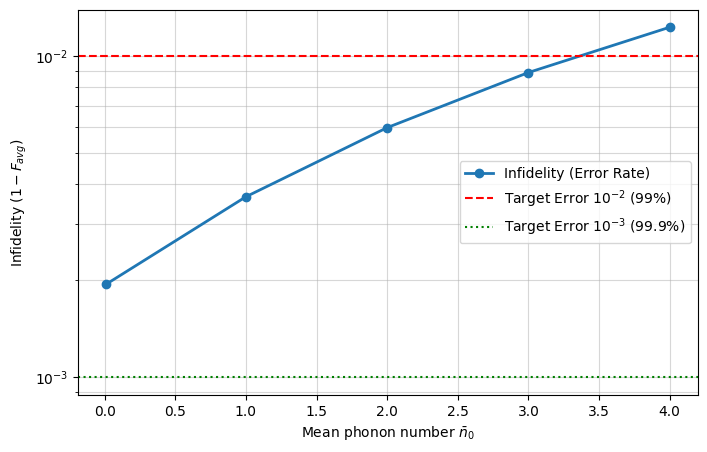

--- Result Summary (Error Rate) ---
n_bar = 0.01: Error = 1.946495e-03 (Fidelity = 0.998054)
n_bar = 1: Error = 3.644359e-03 (Fidelity = 0.996356)
n_bar = 2: Error = 5.980720e-03 (Fidelity = 0.994019)
n_bar = 3: Error = 8.877633e-03 (Fidelity = 0.991122)
n_bar = 4: Error = 1.228076e-02 (Fidelity = 0.987719)


In [1]:
# Infidelity を生成するセル
import importlib
import numpy as np
import pandas as pd
import ms_gate_functions as mg
import stim_pauli_noise as spn

mg = importlib.reload(mg)
spn = importlib.reload(spn)

# --- MS gate parameters ---
A = 0.125
delta = 0.5
rho0 = 0.0
n_bar_list = [0.01, 1, 2, 3, 4]
time_points = 500
t_gate_phys = 100e-6
eta = 0.1


# --- Decoherence / scattering rates in physical time ---
heating_rate_phys = 10.0
dephasing_rate_phys = 18.0
T2_star = 0.3
rayleigh_rate_phys = 3.0
raman_rate_phys = 1.0

# --- Static / quasi-static laser noise ---
laser_intensity_fluctuation = 0#0.015  # fractional RMS of A
laser_detuning_fluctuation_phys = 0#2 * np.pi * 0.3e3  # rad/s RMS
t_gate_sim = 2 * np.pi / delta
laser_detuning_fluctuation = laser_detuning_fluctuation_phys * t_gate_phys / t_gate_sim
laser_rotation_angle_fluctuation = 0#0.1  # rad RMS
laser_noise_samples = 1
laser_noise_seed = 1234

simulation_params = {
    "A": A,
    "delta": delta,
    "rho0": rho0,
    "n_bar_list": n_bar_list,
    "time_points": time_points,
    "t_gate_phys": t_gate_phys,
    "heating_rate_phys": heating_rate_phys,
    "dephasing_rate_phys": dephasing_rate_phys,
    "T2_star": T2_star,
    "rayleigh_rate_phys": rayleigh_rate_phys,
    "raman_rate_phys": raman_rate_phys,
    "eta": eta,
    "laser_intensity_fluctuation": laser_intensity_fluctuation,
    "laser_detuning_fluctuation": laser_detuning_fluctuation,
    "laser_rotation_angle_fluctuation": laser_rotation_angle_fluctuation,
    "laser_noise_samples": laser_noise_samples,
    "laser_noise_seed": laser_noise_seed,
    "use_full_order": True,
    "show_progress": True,
}

infidelity_result = mg.run_infidelity_analysis(
    **simulation_params,
    show_plot=True,
)
infidelity_list = infidelity_result["infidelity_list"]
f_avg_list = infidelity_result["f_avg_list"]


--- Chi Matrix Summary ---
n_bar = 0.01: shape = (16, 16), trace = 15.999999999999996
--- Error Channel Summary ---
Convention: undo_before_actual
n_bar = 0.01: error chi shape = (16, 16), trace = 15.999999999999991, ||PTM - I|| = 7.8320e-02
Saved Pauli-twirled error probabilities: pauli_twirled_error_probabilities.csv
chi heatmaps will be generated for n_bar values: [np.float64(0.01)]
Exact/noisy channel chi, n_bar=0.01: trace before normalization = 15.999999999999993, after = 1.0
Post-gate noise channel chi, n_bar=0.01: trace before normalization = 15.999999999999993, after = 1.0
Post-gate noise channel chi, n_bar=0.01: display-only chi[II,II] was set to 0. Original value = 0.9975668340156426
Saved:
chi_heatmaps/exact_channel_chi_nbar_0p01.png
chi_heatmaps/exact_channel_chi_nbar_0p01.pdf
chi_heatmaps/post_gate_noise_chi_identity_removed_display_nbar_0p01.png
chi_heatmaps/post_gate_noise_chi_identity_removed_display_nbar_0p01.pdf


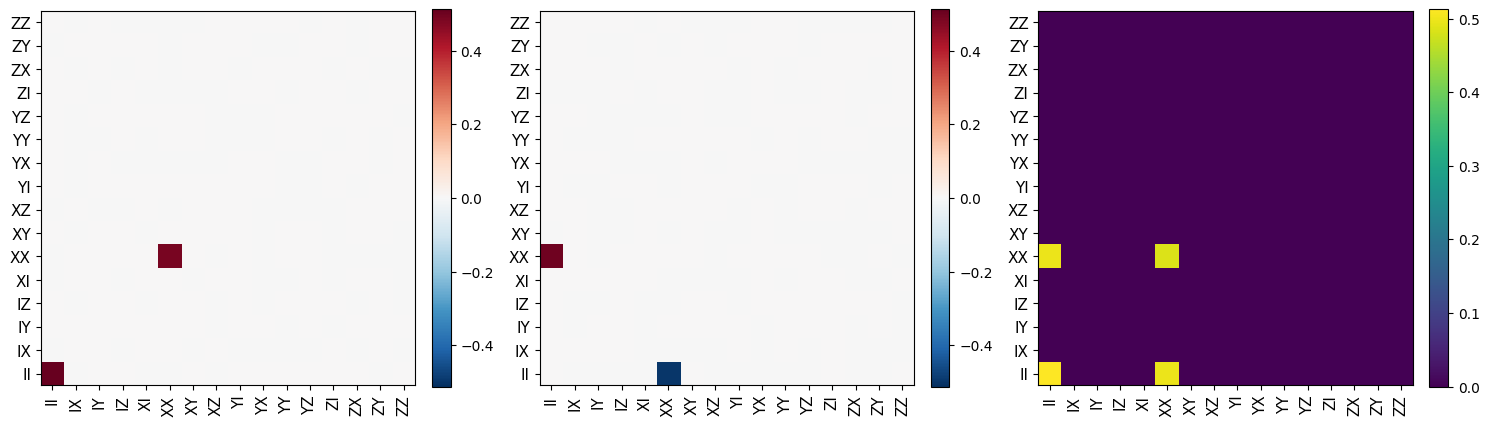

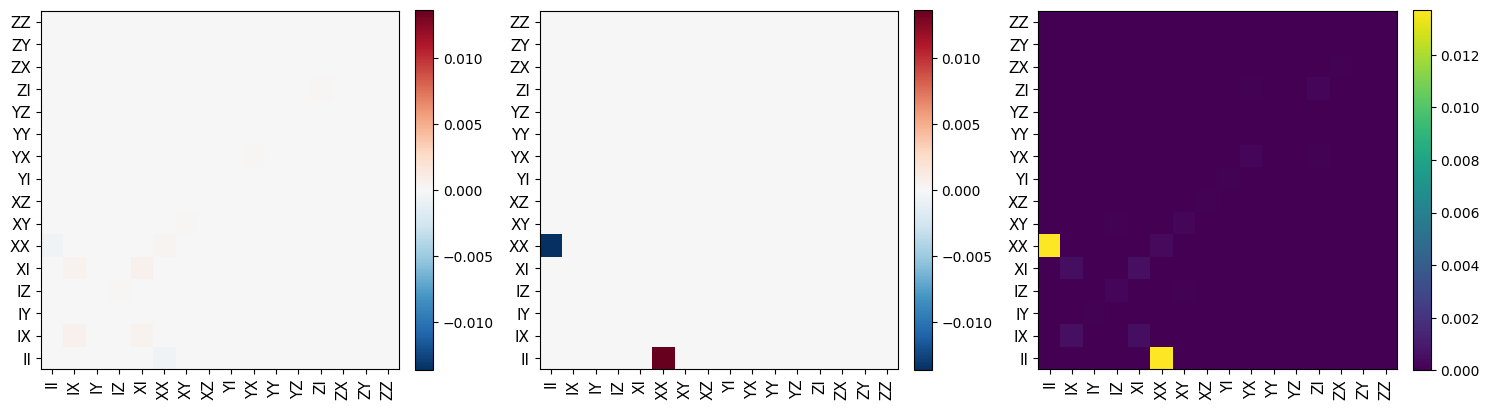

In [5]:
# chi 行列を生成・可視化
# exact/noisy channel の chi と、理想ゲートを除いた post-gate noise channel の chi を同時に表示します。
# デフォルトでは n_bar_list の全点を出力します。特定の点だけ見たい場合は例: chi_plot_n_bar_values = [4]
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import ms_gate_functions as mg
import stim_pauli_noise as spn

mg = importlib.reload(mg)
spn = importlib.reload(spn)

chi_result = mg.generate_chi_matrices(
    simulation_result=infidelity_result,
    show_summary=True,
)
chi_qobj_list = chi_result["chi_qobj_list"]
chi_matrix_list = chi_result["chi_matrix_list"]
chi_by_n_bar = chi_result["chi_by_n_bar"]

error_result = mg.generate_error_channel_matrices(
    channel_result=chi_result,
    convention="undo_before_actual",
    show_summary=True,
)
S_error_qobj_list = error_result["S_error_qobj_list"]
error_chi_qobj_list = error_result["error_chi_qobj_list"]
error_chi_matrix_list = error_result["error_chi_matrix_list"]
error_ptm_list = error_result["error_ptm_list"]
error_chi_by_n_bar = error_result["error_chi_by_n_bar"]
error_ptm_by_n_bar = error_result["error_ptm_by_n_bar"]

pauli_error_csv_path = Path("pauli_twirled_error_probabilities.csv")
spn.save_pauli_error_csv(error_result, pauli_error_csv_path)
pauli_error_probability_df = pd.read_csv(pauli_error_csv_path)
print("Saved Pauli-twirled error probabilities:", pauli_error_csv_path)


def _lookup_by_float_key(mapping, key):
    for candidate_key, value in mapping.items():
        if abs(float(candidate_key) - float(key)) < 1e-12:
            return value
    raise KeyError(f"n_bar={key} was not found. Available values: {list(mapping.keys())}")


def _safe_filename_value(value):
    return str(value).replace("-", "m").replace(".", "p")


def _trace_normalize_chi(chi, label):
    chi_matrix = chi.full() if hasattr(chi, "full") else np.asarray(chi, dtype=complex)
    trace_before = np.trace(chi_matrix)
    if abs(trace_before) < 1e-15:
        raise ValueError(f"{label}: trace is too close to zero and cannot be normalized.")
    chi_normalized = chi_matrix / trace_before
    trace_after = np.trace(chi_normalized)
    print(
        f"{label}: trace before normalization = {np.real_if_close(trace_before)}, "
        f"after = {np.real_if_close(trace_after)}"
    )
    return chi_normalized


def _zero_identity_component_for_display(chi, label):
    chi_display = np.array(chi, dtype=complex, copy=True)
    original_identity = chi_display[0, 0]
    chi_display[0, 0] = 0.0
    print(
        f"{label}: display-only chi[II,II] was set to 0. "
        f"Original value = {np.real_if_close(original_identity)}"
    )
    return chi_display


def _as_nbar_list(requested_values, available_values):
    available_values = list(available_values)
    if requested_values is None:
        return available_values
    if np.isscalar(requested_values):
        requested_values = [requested_values]

    selected = []
    for requested in requested_values:
        matched = min(available_values, key=lambda value: abs(float(value) - float(requested)))
        if not np.isclose(float(matched), float(requested)):
            raise ValueError(
                f"Requested n_bar={requested} is not available. "
                f"Available values: {available_values}"
            )
        selected.append(matched)
    return selected


# None: n_bar_list の全点を出力します。例: [4] にすると n_bar=4 のみ出力します。
chi_plot_n_bar_values = None
chi_plot_n_bar_values = _as_nbar_list(
    chi_plot_n_bar_values,
    chi_result["parameters"]["n_bar_list"],
)
print("chi heatmaps will be generated for n_bar values:", chi_plot_n_bar_values)

chi_heatmap_output_dir = Path("chi_heatmaps")
chi_heatmap_output_dir.mkdir(parents=True, exist_ok=True)

trace_normalized_chi_by_n_bar = {}
trace_normalized_post_noise_chi_by_n_bar = {}
post_noise_chi_identity_removed_display_by_n_bar = {}
chi_heatmap_figures = {}

for chi_plot_n_bar in chi_plot_n_bar_values:
    chi_to_plot_raw = _lookup_by_float_key(chi_by_n_bar, chi_plot_n_bar)
    post_noise_chi_to_plot_raw = _lookup_by_float_key(error_chi_by_n_bar, chi_plot_n_bar)

    chi_to_plot = _trace_normalize_chi(
        chi_to_plot_raw,
        f"Exact/noisy channel chi, n_bar={chi_plot_n_bar}",
    )
    post_noise_chi_normalized = _trace_normalize_chi(
        post_noise_chi_to_plot_raw,
        f"Post-gate noise channel chi, n_bar={chi_plot_n_bar}",
    )
    post_noise_chi_to_plot = _zero_identity_component_for_display(
        post_noise_chi_normalized,
        f"Post-gate noise channel chi, n_bar={chi_plot_n_bar}",
    )

    trace_normalized_chi_by_n_bar[chi_plot_n_bar] = chi_to_plot
    trace_normalized_post_noise_chi_by_n_bar[chi_plot_n_bar] = post_noise_chi_normalized
    post_noise_chi_identity_removed_display_by_n_bar[chi_plot_n_bar] = post_noise_chi_to_plot

    _nbar_label = _safe_filename_value(chi_plot_n_bar)

    fig_chi, axes_chi = mg.plot_chi_matrix(
        chi_to_plot,
        title=None,
        components=("real", "imag", "abs"),
        figsize=(15.0, 5.0),
        show_title=False,
        show_component_titles=False,
        show_axis_labels=False,
        tick_labelsize=11,
        colorbar_tick_labelsize=10,
    )
    fig_chi.savefig(
        chi_heatmap_output_dir / f"exact_channel_chi_nbar_{_nbar_label}.png",
        dpi=300,
        bbox_inches="tight",
    )
    fig_chi.savefig(
        chi_heatmap_output_dir / f"exact_channel_chi_nbar_{_nbar_label}.pdf",
        bbox_inches="tight",
    )

    fig_post_noise_chi, axes_post_noise_chi = mg.plot_chi_matrix(
        post_noise_chi_to_plot,
        title=None,
        components=("real", "imag", "abs"),
        figsize=(15.0, 5.0),
        show_title=False,
        show_component_titles=False,
        show_axis_labels=False,
        tick_labelsize=11,
        colorbar_tick_labelsize=10,
    )
    fig_post_noise_chi.savefig(
        chi_heatmap_output_dir / f"post_gate_noise_chi_identity_removed_display_nbar_{_nbar_label}.png",
        dpi=300,
        bbox_inches="tight",
    )
    fig_post_noise_chi.savefig(
        chi_heatmap_output_dir / f"post_gate_noise_chi_identity_removed_display_nbar_{_nbar_label}.pdf",
        bbox_inches="tight",
    )

    chi_heatmap_figures[chi_plot_n_bar] = {
        "exact": fig_chi,
        "post_noise_identity_removed_display": fig_post_noise_chi,
    }

    print("Saved:")
    print(chi_heatmap_output_dir / f"exact_channel_chi_nbar_{_nbar_label}.png")
    print(chi_heatmap_output_dir / f"exact_channel_chi_nbar_{_nbar_label}.pdf")
    print(chi_heatmap_output_dir / f"post_gate_noise_chi_identity_removed_display_nbar_{_nbar_label}.png")
    print(chi_heatmap_output_dir / f"post_gate_noise_chi_identity_removed_display_nbar_{_nbar_label}.pdf")


In [ ]:
# 理想ゲートを除いた error channel の chi / PTM を生成・可視化
import importlib
import ms_gate_functions as mg

mg = importlib.reload(mg)

error_result = mg.generate_error_channel_matrices(
    channel_result=chi_result,
    convention="undo_before_actual",
    show_summary=True,
)

S_error_qobj_list = error_result["S_error_qobj_list"]
error_chi_qobj_list = error_result["error_chi_qobj_list"]
error_chi_matrix_list = error_result["error_chi_matrix_list"]
error_ptm_list = error_result["error_ptm_list"]
error_chi_by_n_bar = error_result["error_chi_by_n_bar"]
error_ptm_by_n_bar = error_result["error_ptm_by_n_bar"]

# 見たい n_bar を選択。
error_plot_n_bar = 4
if error_plot_n_bar is None:
    error_plot_n_bar = error_result["parameters"]["n_bar_list"][0]

error_chi_to_plot = error_chi_by_n_bar[error_plot_n_bar]
error_ptm_to_plot = error_ptm_by_n_bar[error_plot_n_bar]

fig_error_chi, axes_error_chi = mg.plot_chi_matrix(
    error_chi_to_plot,
    title=None,
    components=("real", "imag", "abs"),
    figsize=(15.0, 5.0),
    show_title=False,
    show_component_titles=False,
    show_axis_labels=False,
    tick_labelsize=11,
    colorbar_tick_labelsize=10,
)

fig_error_ptm, ax_error_ptm = mg.plot_ptm(
    error_ptm_to_plot,
    title=None,
    figsize=(5.8, 5.2),
    show_title=False,
    show_axis_labels=False,
    tick_labelsize=11,
    colorbar_tick_labelsize=10,
)

# --- chi scalar summary execution ---
chi_scalar_summary_df, chi_scalar_figures, chi_derivative_top_df = mg.run_error_chi_scalar_summary(
    error_result,
    output_dir="chi_scalar_summary",
    top_derivative_index=0,
    top_k=20,
)

chi_scalar_summary_df



### QIT発表用セル

,nbar,trace_normalized,raw_chi_trace,D_off_chi,D_II_P_chi,D_P_II_chi,D_IE_chi,D_EE_chi,IE_fraction,EE_fraction
0,0.01,True,16.0,0.019406,0.013712,0.013712,0.019391,0.000755,0.998487,0.001513
1,1.00,True,16.0,0.040592,0.028684,0.028684,0.040565,0.001478,0.998674,0.001326
2,2.00,True,16.0,0.061419,0.043403,0.043403,0.061381,0.002170,0.998752,0.001248
3,3.00,True,16.0,0.081608,0.057671,0.057671,0.081559,0.002820,0.998806,0.001194
4,4.00,True,16.0,0.101106,0.071451,0.071451,0.101048,0.003433,0.998847,0.001153


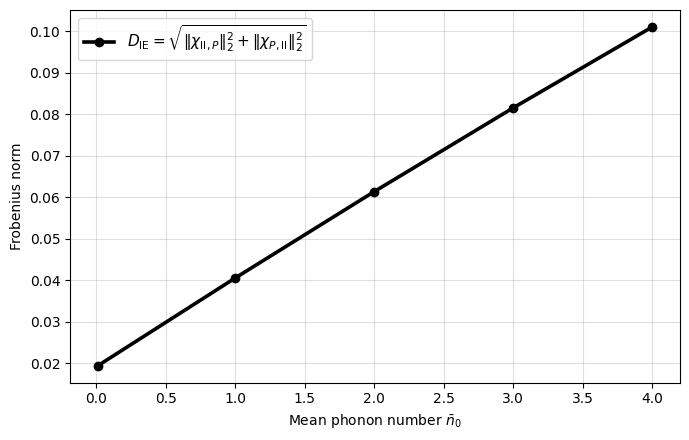

In [27]:
# 発表用: Tr(chi)=1 に規格化した error chi の II,P / P,II 成分だけをプロット
import importlib
import ms_gate_functions as mg

mg = importlib.reload(mg)

chi_offdiag_presentation_df, chi_offdiag_presentation_figures = (
    mg.plot_chi_offdiagonal_presentation_summary(
        error_result,
        output_dir="presentation_chi_offdiag_trace_normalized",
        trace_normalize=True,
        make_backup_figures=False,
    )
)

chi_offdiag_presentation_df


Infidelity vs error rate を n_bar = 0.1 で計算します。
--- Noise Source Strength Sweep ---
s values: [0.0, 0.5, 1.0, 2.0, 4.0]
selected nbar: 0.1
active sources: ['motional_heating', 'motional_dephasing', 'spin_dephasing', 'photon_scattering']
--- source = motional_heating, nominal strength = 10.0 ---


MS gate simulation (16 evolutions / n_bar):   0%|          | 0/16 [00:00<?, ?evolution/s]

s = 0.0: strength = 0.0


MS gate simulation (16 evolutions / n_bar):   0%|          | 0/16 [00:00<?, ?evolution/s]

s = 0.5: strength = 5.0


...

MS gate simulation (16 evolutions / n_bar):   0%|          | 0/16 [00:00<?, ?evolution/s]

s = 2.0: strength = 8.0


MS gate simulation (16 evolutions / n_bar):   0%|          | 0/16 [00:00<?, ?evolution/s]

s = 4.0: strength = 16.0
Saved: outputs/noise_source_infidelity_vs_error_rate_nbar_0p1.csv
Saved: outputs/noise_source_infidelity_vs_error_rate_nbar_0p1_panel.png/pdf
Saved: outputs/noise_source_infidelity_vs_error_rate_nbar_0p1_<noise_source>.png/pdf
--- Noise-source infidelity sweep at n_bar = 0.1 ---
      noise_source   s  error_rate  nbar    F_avg  infidelity  trace_R_post
motional_dephasing 0.0    0.000000   0.1 0.999684    0.000316     15.993680
motional_dephasing 0.5    9.000000   0.1 0.999412    0.000588     15.988234
motional_dephasing 1.0   18.000000   0.1 0.999140    0.000860     15.982797
motional_dephasing 2.0   36.000000   0.1 0.998598    0.001402     15.971951
motional_dephasing 4.0   72.000000   0.1 0.997519    0.002481     15.950371
  motional_heating 0.0    0.000000   0.1 0.999684    0.000316     15.993680
  motional_heating 0.5    5.000000   0.1 0.999489    0.000511     15.989786
  motional_heating 1.0   10.000000   0.1 0.999295    0.000705     15.985895
  motional_

,noise_source,s,error_rate,nbar,F_avg,infidelity,trace_R_post
0,motional_dephasing,0.0,0.000000,0.1,0.999684,0.000316,15.993680
1,motional_dephasing,0.5,9.000000,0.1,0.999412,0.000588,15.988234
2,motional_dephasing,1.0,18.000000,0.1,0.999140,0.000860,15.982797
3,motional_dephasing,2.0,36.000000,0.1,0.998598,0.001402,15.971951
4,motional_dephasing,4.0,72.000000,0.1,0.997519,0.002481,15.950371
5,motional_heating,0.0,0.000000,0.1,0.999684,0.000316,15.993680
6,motional_heating,0.5,5.000000,0.1,0.999489,0.000511,15.989786
7,motional_heating,1.0,10.000000,0.1,0.999295,0.000705,15.985895
8,motional_heating,2.0,20.000000,0.1,0.998906,0.001094,15.978119
9,motional_heating,4.0,40.000000,0.1,0.998130,0.001870,15.962596


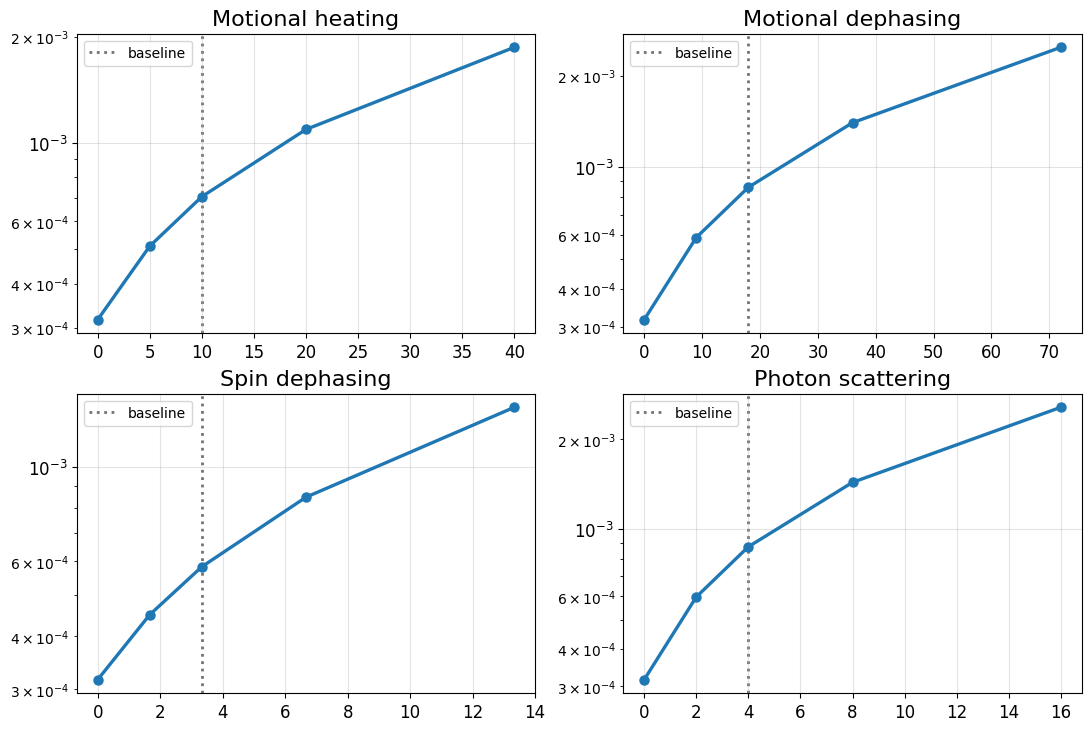

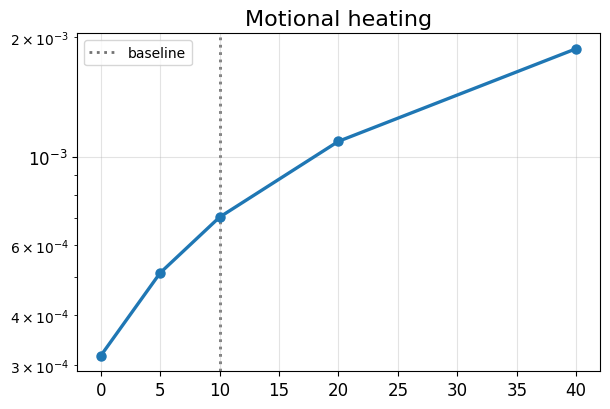

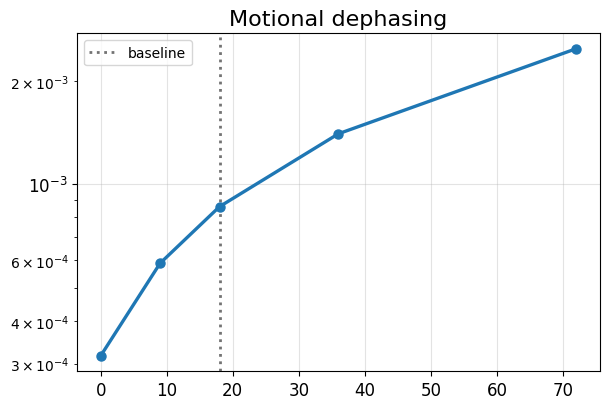

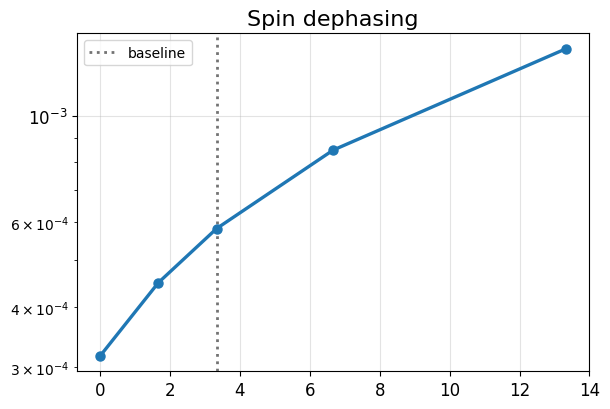

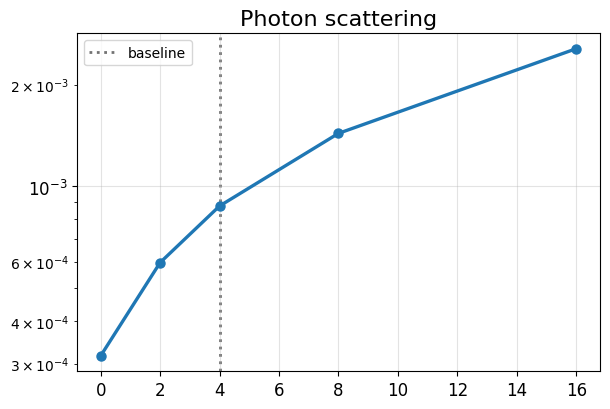

In [10]:
# Figure A/D/E/F/G: post-gate noise channel summary figures
# 現在は n_bar = 0.1 固定で、4つの主要ノイズ源について
# Infidelity vs actual error rate のみを出力します。
import importlib
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ms_gate_functions as mg

mg = importlib.reload(mg)

noise_source_infidelity_nbar = 0.1
post_gate_s_values = [0.0, 0.5, 1.0, 2.0, 4.0]
noise_source_infidelity_sources = [
    "motional_heating",
    "motional_dephasing",
    "spin_dephasing",
    "photon_scattering",
]
noise_source_plot_labels = {
    "motional_heating": "Motional heating",
    "motional_dephasing": "Motional dephasing",
    "spin_dephasing": "Spin dephasing",
    "photon_scattering": "Photon scattering",
}

infidelity_output_dir = Path("outputs")
infidelity_output_dir.mkdir(parents=True, exist_ok=True)

print("Infidelity vs error rate を n_bar = 0.1 で計算します。")
noise_source_infidelity_base_parameters = dict(
    globals().get("simulation_params", error_result.get("parameters", {}))
)
_allowed_simulation_keys = set(
    mg.run_ms_gate_simulation.__code__.co_varnames[:mg.run_ms_gate_simulation.__code__.co_argcount]
)
noise_source_infidelity_base_parameters = {
    key: value
    for key, value in noise_source_infidelity_base_parameters.items()
    if key in _allowed_simulation_keys
}
noise_source_infidelity_base_parameters["n_bar_list"] = [noise_source_infidelity_nbar]

noise_source_infidelity_sweep_results = mg.run_noise_source_strength_sweep(
    base_parameters=noise_source_infidelity_base_parameters,
    noise_sources=noise_source_infidelity_sources,
    s_values=post_gate_s_values,
    selected_nbar=noise_source_infidelity_nbar,
    convention="undo_before_actual",
    show_summary=True,
)


def average_gate_fidelity_from_error_ptm(R_post, dimension=4):
    R_post = np.asarray(R_post, dtype=complex)
    expected_shape = (dimension ** 2, dimension ** 2)
    if R_post.shape != expected_shape:
        raise ValueError(f"R_post must have shape {expected_shape}; got {R_post.shape}.")
    trace_R = np.trace(R_post)
    if abs(np.imag(trace_R)) > 1e-12:
        warnings.warn(f"PTM trace has imaginary part {np.imag(trace_R):.3e}; using real part.")
    return float(np.real(trace_R) + dimension) / (dimension * (dimension + 1))


def build_noise_source_infidelity_summary(sweep_results, dimension=4):
    rows = []
    for noise_source, source_data in sweep_results.items():
        points = source_data.get("points", source_data) if isinstance(source_data, dict) else source_data
        for point in points:
            R_post = point.get("R_post", point.get("R", point.get("error_ptm")))
            if R_post is None:
                raise KeyError(f"{noise_source}: each point must contain R_post, R, or error_ptm.")
            F_avg = average_gate_fidelity_from_error_ptm(R_post, dimension=dimension)
            error_rate = float(point.get("strength", np.nan))
            rows.append(
                {
                    "noise_source": noise_source,
                    "s": float(point.get("s", np.nan)),
                    "error_rate": error_rate,
                    "nbar": float(point.get("nbar", noise_source_infidelity_nbar)),
                    "F_avg": F_avg,
                    "infidelity": float(1.0 - F_avg),
                    "trace_R_post": float(np.real(np.trace(np.asarray(R_post, dtype=complex)))),
                }
            )
    return pd.DataFrame(rows).sort_values(["noise_source", "error_rate"]).reset_index(drop=True)


noise_source_infidelity_sweep_df = build_noise_source_infidelity_summary(
    noise_source_infidelity_sweep_results,
    dimension=4,
)
noise_source_infidelity_sweep_path = infidelity_output_dir / "noise_source_infidelity_vs_error_rate_nbar_0p1.csv"
noise_source_infidelity_sweep_df.to_csv(noise_source_infidelity_sweep_path, index=False)


def baseline_error_rate_from_group(group, baseline_s=1.0):
    if group.empty:
        return np.nan
    index = (group["s"].astype(float) - float(baseline_s)).abs().idxmin()
    return float(group.loc[index, "error_rate"])


def draw_error_rate_baseline(ax, baseline_error_rate, label="baseline"):
    if not np.isfinite(baseline_error_rate):
        return
    ax.axvline(
        baseline_error_rate,
        color="0.45",
        linestyle=":",
        linewidth=2.0,
        label=label,
        zorder=0,
    )


fig_noise_source_infidelity_panel, axes_noise_source_infidelity = plt.subplots(
    2,
    2,
    figsize=(10.8, 7.2),
    constrained_layout=True,
)
axes_noise_source_infidelity = axes_noise_source_infidelity.ravel()

for ax, noise_source in zip(axes_noise_source_infidelity, noise_source_infidelity_sources):
    group = noise_source_infidelity_sweep_df[
        noise_source_infidelity_sweep_df["noise_source"] == noise_source
    ].sort_values("error_rate")
    if group.empty:
        ax.axis("off")
        continue
    baseline_error_rate = baseline_error_rate_from_group(group, baseline_s=1.0)
    draw_error_rate_baseline(ax, baseline_error_rate)
    ax.plot(
        group["error_rate"],
        group["infidelity"],
        color="tab:blue",
        marker="o",
        linewidth=2.4,
        markersize=6.5,
    )
    ax.set_title(noise_source_plot_labels.get(noise_source, noise_source), fontsize=16)
    ax.set_yscale("log")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="both", labelsize=12)
    ax.ticklabel_format(axis="x", style="sci", scilimits=(-2, 3))
    ax.grid(True, alpha=0.35)
    ax.legend(fontsize=10, frameon=True)

fig_noise_source_infidelity_panel.savefig(
    infidelity_output_dir / "noise_source_infidelity_vs_error_rate_nbar_0p1_panel.png",
    dpi=300,
    bbox_inches="tight",
)
fig_noise_source_infidelity_panel.savefig(
    infidelity_output_dir / "noise_source_infidelity_vs_error_rate_nbar_0p1_panel.pdf",
    bbox_inches="tight",
)

for noise_source in noise_source_infidelity_sources:
    group = noise_source_infidelity_sweep_df[
        noise_source_infidelity_sweep_df["noise_source"] == noise_source
    ].sort_values("error_rate")
    if group.empty:
        continue
    fig_single, ax_single = plt.subplots(figsize=(6.2, 4.2))
    baseline_error_rate = baseline_error_rate_from_group(group, baseline_s=1.0)
    draw_error_rate_baseline(ax_single, baseline_error_rate)
    ax_single.plot(
        group["error_rate"],
        group["infidelity"],
        color="tab:blue",
        marker="o",
        linewidth=2.4,
        markersize=6.5,
    )
    ax_single.set_title(noise_source_plot_labels.get(noise_source, noise_source), fontsize=16)
    ax_single.set_yscale("log")
    ax_single.set_xlabel("")
    ax_single.set_ylabel("")
    ax_single.tick_params(axis="both", labelsize=12)
    ax_single.ticklabel_format(axis="x", style="sci", scilimits=(-2, 3))
    ax_single.grid(True, alpha=0.35)
    ax_single.legend(fontsize=10, frameon=True)
    fig_single.tight_layout()
    fig_single.savefig(
        infidelity_output_dir / f"noise_source_infidelity_vs_error_rate_nbar_0p1_{noise_source}.png",
        dpi=300,
        bbox_inches="tight",
    )
    fig_single.savefig(
        infidelity_output_dir / f"noise_source_infidelity_vs_error_rate_nbar_0p1_{noise_source}.pdf",
        bbox_inches="tight",
    )

print(f"Saved: {noise_source_infidelity_sweep_path}")
print("Saved: outputs/noise_source_infidelity_vs_error_rate_nbar_0p1_panel.png/pdf")
print("Saved: outputs/noise_source_infidelity_vs_error_rate_nbar_0p1_<noise_source>.png/pdf")
print("--- Noise-source infidelity sweep at n_bar = 0.1 ---")
print(noise_source_infidelity_sweep_df.to_string(index=False))

noise_source_infidelity_sweep_df


--- Superoperator channel distance sanity check ---
 nbar shape_S_exact shape_S_PT shape_S_dep  all_shapes_16x16  all_distances_finite  D_abs_exact_PT_nonnegative  D_abs_exact_dep_nonnegative  self_distance_exact_exact  self_distance_is_zero
 0.01      (16, 16)   (16, 16)    (16, 16)              True                  True                        True                         True                        0.0                   True
 1.00      (16, 16)   (16, 16)    (16, 16)              True                  True                        True                         True                        0.0                   True
 2.00      (16, 16)   (16, 16)    (16, 16)              True                  True                        True                         True                        0.0                   True
 3.00      (16, 16)   (16, 16)    (16, 16)              True                  True                        True                         True                        0.0                   Tru

,nbar,D_TV_cond
0,0.01,0.415899
1,1.00,0.584302
2,2.00,0.668564
3,3.00,0.711453
4,4.00,0.735991


,nbar,p_err_exact,p_w1_exact,p_w2_exact,fraction_w1_given_error_exact,fraction_w2_given_error_exact,ratio_w2_over_w1_exact,p_err_PT,p_w1_PT,p_w2_PT,...,ratio_w2_over_w1_dep,delta_p_err_PT_minus_dep,delta_p_w1_PT_minus_dep,delta_p_w2_PT_minus_dep,L1_distance_PT_dep,total_variation_distance_PT_dep,D_TV_cond,L2_distance_PT_dep,sum_p_PT,sum_p_dep
0,0.01,0.002433,0.001589,0.000844,0.653108,0.346892,0.531140,0.002433,0.001589,0.000844,...,1.5,-1.110223e-16,0.000616,-0.000616,0.002024,0.001012,0.415899,0.000689,1.0,1.0
1,1.00,0.004555,0.002621,0.001934,0.575384,0.424616,0.737969,0.004555,0.002621,0.001934,...,1.5,0.000000e+00,0.000799,-0.000799,0.005324,0.002662,0.584302,0.001759,1.0,1.0
2,2.00,0.007476,0.003602,0.003873,0.481872,0.518128,1.075238,0.007476,0.003602,0.003873,...,1.5,-3.330669e-16,0.000612,-0.000612,0.009996,0.004998,0.668564,0.003560,1.0,1.0
3,3.00,0.011097,0.004523,0.006574,0.407563,0.592437,1.453607,0.011097,0.004523,0.006574,...,1.5,5.551115e-16,0.000084,-0.000084,0.015790,0.007895,0.711453,0.006086,1.0,1.0
4,4.00,0.015351,0.005391,0.009960,0.351164,0.648836,1.847673,0.015351,0.005391,0.009960,...,1.5,1.110223e-16,-0.000750,0.000750,0.022596,0.011298,0.735991,0.009278,1.0,1.0


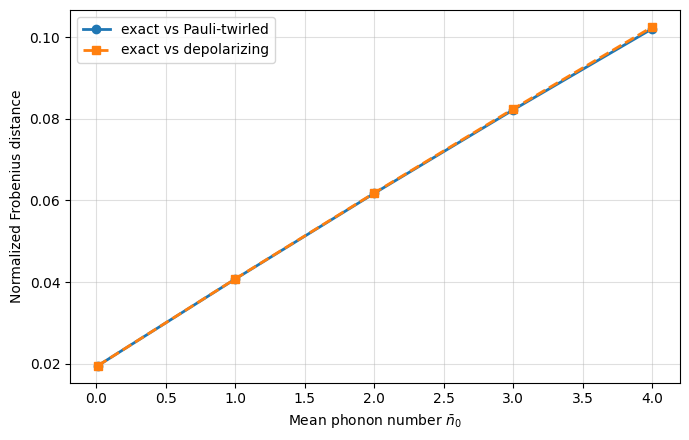

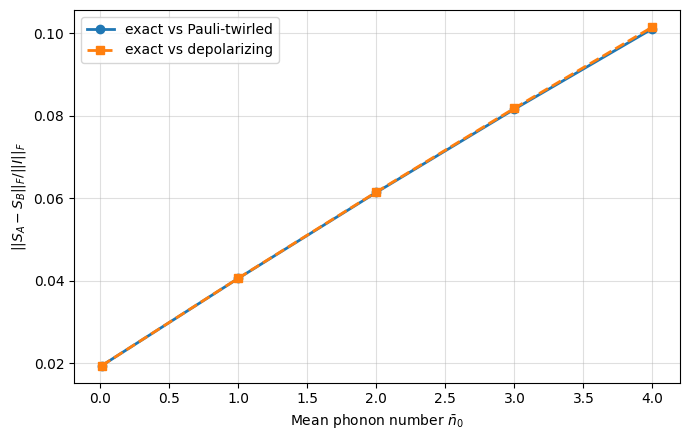

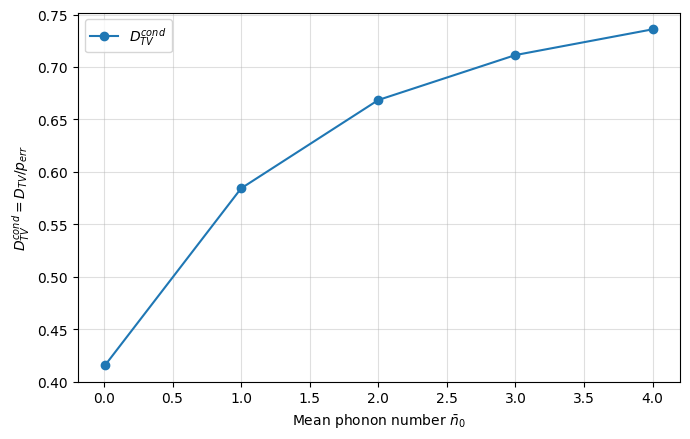

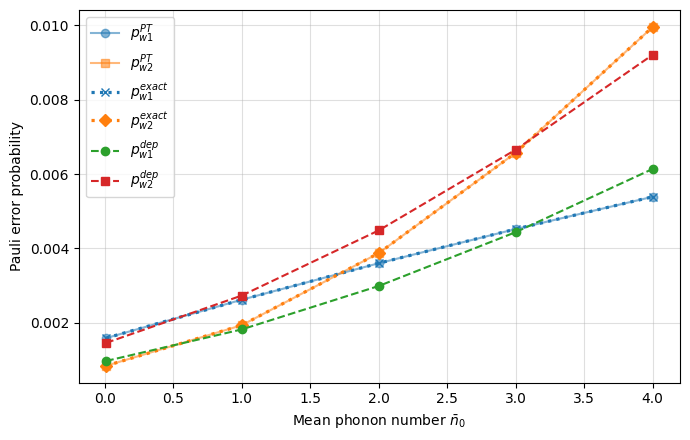

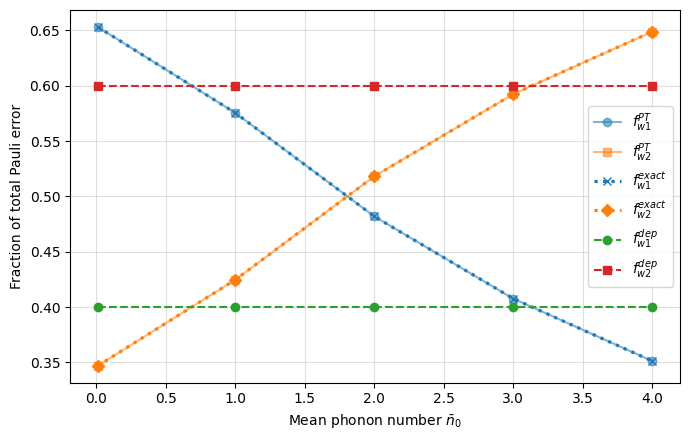

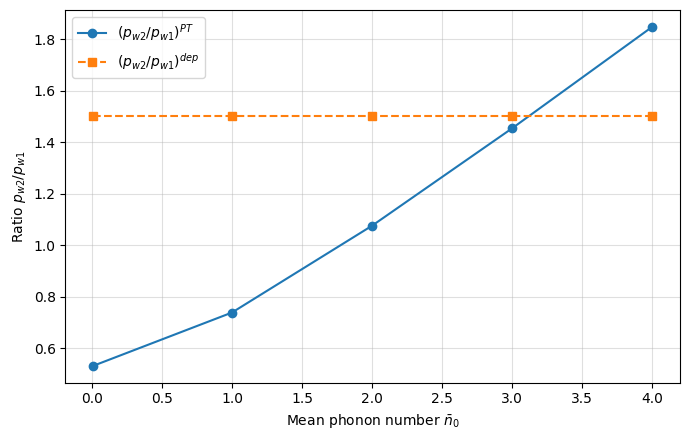

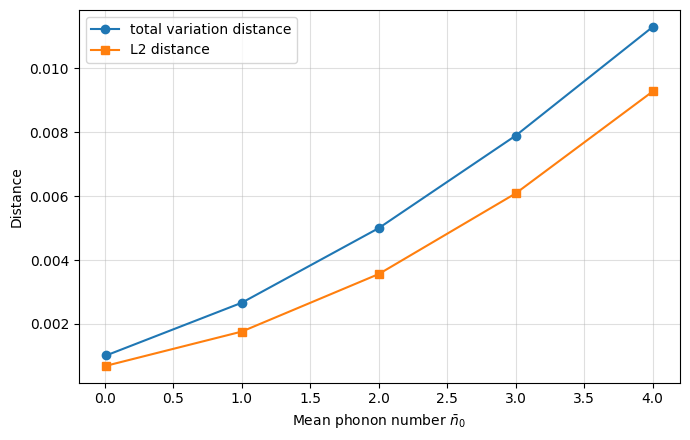

In [6]:
# Superoperator distance: exact post-gate channel vs Pauli-twirled / depolarizing channels
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import qutip as qp
import ms_gate_functions as mg

pauli_labels_superop = [
    "II", "IX", "IY", "IZ",
    "XI", "XX", "XY", "XZ",
    "YI", "YX", "YY", "YZ",
    "ZI", "ZX", "ZY", "ZZ",
]

superop_distance_output_dir = Path("superoperator_channel_distance_summary")
superop_distance_output_dir.mkdir(parents=True, exist_ok=True)


def frobenius_distance(A, B):
    A = np.asarray(A, dtype=complex)
    B = np.asarray(B, dtype=complex)
    return float(np.linalg.norm(A - B, ord="fro"))


def normalized_frobenius_distance(A, B):
    A = np.asarray(A, dtype=complex)
    denominator = np.linalg.norm(A, ord="fro")
    if denominator < 1e-15:
        return np.nan
    return frobenius_distance(A, B) / denominator


def identity_normalized_distance(A, B):
    A = np.asarray(A, dtype=complex)
    identity_super = np.eye(A.shape[0], dtype=complex)
    denominator = np.linalg.norm(identity_super, ord="fro")
    if denominator < 1e-15:
        return np.nan
    return frobenius_distance(A, B) / denominator


def _dense_superoperator(S):
    if hasattr(S, "full"):
        return np.asarray(S.full(), dtype=complex)
    return np.asarray(S, dtype=complex)


def _two_qubit_pauli_operators_from_labels(pauli_labels):
    one_qubit_paulis = {
        "I": qp.identity(2),
        "X": qp.sigmax(),
        "Y": qp.sigmay(),
        "Z": qp.sigmaz(),
    }
    return [
        qp.tensor(one_qubit_paulis[label[0]], one_qubit_paulis[label[1]])
        for label in pauli_labels
    ]


def _pauli_conjugation_superoperators(pauli_labels):
    pauli_ops = _two_qubit_pauli_operators_from_labels(pauli_labels)
    return [_dense_superoperator(qp.to_super(P)) for P in pauli_ops]


def pauli_twirl_superoperator(S_exact, pauli_labels=pauli_labels_superop):
    S_exact = np.asarray(S_exact, dtype=complex)
    pauli_superoperators = _pauli_conjugation_superoperators(pauli_labels)
    S_PT = np.zeros_like(S_exact, dtype=complex)
    for C_P in pauli_superoperators:
        S_PT = S_PT + (C_P @ S_exact @ C_P)
    return S_PT / len(pauli_superoperators)


def average_gate_fidelity_from_superoperator(S_exact, d=4):
    trace_super = np.trace(np.asarray(S_exact, dtype=complex))
    F_avg = (trace_super + d) / (d * (d + 1))
    return float(np.real_if_close(F_avg))


def depolarizing_superoperator_from_exact(S_exact, d=4):
    S_exact = np.asarray(S_exact, dtype=complex)
    d2 = d ** 2
    F_avg = average_gate_fidelity_from_superoperator(S_exact, d=d)
    r = 1.0 - F_avg
    p_dep = ((d + 1) / d) * r
    alpha = 1.0 - (d2 / (d2 - 1)) * p_dep

    identity_super = np.eye(d2, dtype=complex)
    identity_operator = qp.identity(d)
    identity_vec = qp.operator_to_vector(identity_operator).full()
    trace_to_identity = (identity_vec @ identity_vec.conj().T) / d
    return np.multiply(alpha, identity_super) + np.multiply(1.0 - alpha, trace_to_identity)


def _ideal_inverse_superoperator_array(phi=np.pi / 4):
    ideal_unitary = mg.ideal_ms_gate(phi=phi)
    return _dense_superoperator(qp.to_super(ideal_unitary.dag()))


def build_superoperator_distance_inputs(error_result, phi=np.pi / 4, pauli_labels=pauli_labels_superop):
    if "results_list" not in error_result:
        raise KeyError("error_result must contain results_list with n_bar values.")

    nbar_values = [float(data["n_bar"]) for data in error_result["results_list"]]
    S_exact_list = []

    if "S_qobj_list" in error_result:
        S_ideal_inv = _ideal_inverse_superoperator_array(phi=phi)
        for S_noisy in error_result["S_qobj_list"]:
            S_noisy_dense = _dense_superoperator(S_noisy)
            S_exact_list.append(S_noisy_dense @ S_ideal_inv)
    elif "S_error_qobj_list" in error_result:
        for S_error in error_result["S_error_qobj_list"]:
            S_exact_list.append(_dense_superoperator(S_error))
    else:
        raise KeyError("error_result must contain S_qobj_list or S_error_qobj_list.")

    channel_results = []
    for nbar, S_exact in zip(nbar_values, S_exact_list):
        S_PT = pauli_twirl_superoperator(S_exact, pauli_labels=pauli_labels)
        S_dep = depolarizing_superoperator_from_exact(S_exact, d=4)
        channel_results.append(
            {
                "nbar": nbar,
                "S_exact": S_exact,
                "S_PT": S_PT,
                "S_dep": S_dep,
            }
        )
    return channel_results


def compute_channel_distances(results):
    if isinstance(results, dict):
        iterable = results.values()
    else:
        iterable = results

    rows = []
    sanity_rows = []
    expected_shape = (16, 16)

    for entry in iterable:
        nbar = float(entry["nbar"])
        S_exact = np.asarray(entry["S_exact"], dtype=complex)
        S_PT = np.asarray(entry["S_PT"], dtype=complex)
        S_dep = np.asarray(entry["S_dep"], dtype=complex)

        D_abs_exact_PT = frobenius_distance(S_exact, S_PT)
        D_rel_exact_PT = normalized_frobenius_distance(S_exact, S_PT)
        D_I_exact_PT = identity_normalized_distance(S_exact, S_PT)
        D_abs_exact_dep = frobenius_distance(S_exact, S_dep)
        D_rel_exact_dep = normalized_frobenius_distance(S_exact, S_dep)
        D_I_exact_dep = identity_normalized_distance(S_exact, S_dep)
        self_distance = frobenius_distance(S_exact, S_exact)

        distance_values = [
            D_abs_exact_PT,
            D_rel_exact_PT,
            D_I_exact_PT,
            D_abs_exact_dep,
            D_rel_exact_dep,
            D_I_exact_dep,
        ]

        rows.append(
            {
                "nbar": nbar,
                "D_abs_exact_PT": D_abs_exact_PT,
                "D_rel_exact_PT": D_rel_exact_PT,
                "D_I_exact_PT": D_I_exact_PT,
                "D_abs_exact_dep": D_abs_exact_dep,
                "D_rel_exact_dep": D_rel_exact_dep,
                "D_I_exact_dep": D_I_exact_dep,
            }
        )
        sanity_rows.append(
            {
                "nbar": nbar,
                "shape_S_exact": S_exact.shape,
                "shape_S_PT": S_PT.shape,
                "shape_S_dep": S_dep.shape,
                "all_shapes_16x16": (
                    S_exact.shape == expected_shape
                    and S_PT.shape == expected_shape
                    and S_dep.shape == expected_shape
                ),
                "all_distances_finite": bool(np.all(np.isfinite(distance_values))),
                "D_abs_exact_PT_nonnegative": D_abs_exact_PT >= 0,
                "D_abs_exact_dep_nonnegative": D_abs_exact_dep >= 0,
                "self_distance_exact_exact": self_distance,
                "self_distance_is_zero": np.isclose(self_distance, 0.0, atol=1e-12),
            }
        )

    distance_df = pd.DataFrame(rows).sort_values("nbar").reset_index(drop=True)
    sanity_df = pd.DataFrame(sanity_rows).sort_values("nbar").reset_index(drop=True)
    return distance_df, sanity_df


superoperator_channel_results = build_superoperator_distance_inputs(
    error_result,
    phi=np.pi / 4,
    pauli_labels=pauli_labels_superop,
)

channel_distance_df, channel_distance_sanity_df = compute_channel_distances(
    superoperator_channel_results
)

channel_distance_csv_path = superop_distance_output_dir / "channel_distance_summary.csv"
channel_distance_df.to_csv(channel_distance_csv_path, index=False)

sanity_csv_path = superop_distance_output_dir / "channel_distance_sanity_check.csv"
channel_distance_sanity_df.to_csv(sanity_csv_path, index=False)

print("--- Superoperator channel distance sanity check ---")
print(channel_distance_sanity_df.to_string(index=False))
print(f"Saved: {channel_distance_csv_path}")
print(f"Saved: {sanity_csv_path}")

fig_rel, ax_rel = plt.subplots(figsize=(7, 4.5))
ax_rel.plot(
    channel_distance_df["nbar"],
    channel_distance_df["D_rel_exact_PT"],
    color="tab:blue",
    linestyle="-",
    marker="o",
    linewidth=2.0,
    label="exact vs Pauli-twirled",
)
ax_rel.plot(
    channel_distance_df["nbar"],
    channel_distance_df["D_rel_exact_dep"],
    color="tab:orange",
    linestyle="--",
    marker="s",
    linewidth=2.0,
    label="exact vs depolarizing",
)
ax_rel.set_xlabel(r"Mean phonon number $\bar{n}_0$")
ax_rel.set_ylabel("Normalized Frobenius distance")
ax_rel.grid(True, alpha=0.4)
ax_rel.legend()
fig_rel.tight_layout()
fig_rel.savefig(superop_distance_output_dir / "channel_distance_relative.png", dpi=300, bbox_inches="tight")
fig_rel.savefig(superop_distance_output_dir / "channel_distance_relative.pdf", bbox_inches="tight")

fig_I, ax_I = plt.subplots(figsize=(7, 4.5))
ax_I.plot(
    channel_distance_df["nbar"],
    channel_distance_df["D_I_exact_PT"],
    color="tab:blue",
    linestyle="-",
    marker="o",
    linewidth=2.0,
    label="exact vs Pauli-twirled",
)
ax_I.plot(
    channel_distance_df["nbar"],
    channel_distance_df["D_I_exact_dep"],
    color="tab:orange",
    linestyle="--",
    marker="s",
    linewidth=2.0,
    label="exact vs depolarizing",
)
ax_I.set_xlabel(r"Mean phonon number $\bar{n}_0$")
ax_I.set_ylabel(r"$||S_A-S_B||_F / ||I||_F$")
ax_I.grid(True, alpha=0.4)
ax_I.legend()
fig_I.tight_layout()
fig_I.savefig(superop_distance_output_dir / "channel_distance_identity_normalized.png", dpi=300, bbox_inches="tight")
fig_I.savefig(superop_distance_output_dir / "channel_distance_identity_normalized.pdf", bbox_inches="tight")

channel_distance_df

# Pauli weight distribution comparison: Pauli-twirled vs depolarizing probabilities

def _safe_probability_ratio(numerator, denominator):
    if abs(denominator) < 1e-15:
        return np.nan
    return float(numerator / denominator)


def _real_trace_normalized_chi_diagonal(chi):
    if hasattr(chi, "full"):
        chi = chi.full()
    chi = np.asarray(chi, dtype=complex)
    trace_chi = np.trace(chi)
    if abs(trace_chi) > 1e-15:
        chi = chi / trace_chi
    probabilities = np.real(np.diag(chi)).astype(float)
    probability_sum = np.sum(probabilities)
    if abs(probability_sum) > 1e-15:
        probabilities = probabilities / probability_sum
    return probabilities


def _lookup_by_float_key(mapping, key):
    for candidate_key, value in mapping.items():
        if np.isclose(float(candidate_key), float(key)):
            return value
    raise KeyError(f"nbar={key} was not found.")


def _error_chi_probability_points(error_result, pauli_labels=pauli_labels_superop):
    nbar_values = [float(data["n_bar"]) for data in error_result["results_list"]]

    if "error_chi_matrix_list" in error_result:
        chi_values = error_result["error_chi_matrix_list"]
    elif "error_chi_qobj_list" in error_result:
        chi_values = error_result["error_chi_qobj_list"]
    elif "error_chi_by_n_bar" in error_result:
        chi_by_nbar = error_result["error_chi_by_n_bar"]
        chi_values = [_lookup_by_float_key(chi_by_nbar, nbar) for nbar in nbar_values]
    else:
        raise KeyError("error_result must contain error_chi_matrix_list, error_chi_qobj_list, or error_chi_by_n_bar.")

    return [
        {
            "nbar": nbar,
            "p_PT": _real_trace_normalized_chi_diagonal(chi),
        }
        for nbar, chi in zip(nbar_values, chi_values)
    ]


def _pauli_weight_masks(pauli_labels=pauli_labels_superop):
    weights = np.asarray([sum(char != "I" for char in label) for label in pauli_labels])
    return {
        "weights": weights,
        "w0": weights == 0,
        "w1": weights == 1,
        "w2": weights == 2,
    }


def _depolarizing_pauli_probabilities_from_exact_superoperator(S_exact, d=4):
    F_avg = average_gate_fidelity_from_superoperator(S_exact, d=d)
    r = 1.0 - F_avg
    p_dep = ((d + 1) / d) * r
    p_dep = float(np.real_if_close(p_dep))
    if abs(p_dep) < 1e-15:
        p_dep = 0.0

    probabilities = np.full(d ** 2, p_dep / (d ** 2 - 1), dtype=float)
    probabilities[0] = 1.0 - p_dep
    return probabilities


def _pauli_weight_summary(probabilities, masks):
    probabilities = np.asarray(probabilities, dtype=float)
    p_w0 = float(np.sum(probabilities[masks["w0"]]))
    p_w1 = float(np.sum(probabilities[masks["w1"]]))
    p_w2 = float(np.sum(probabilities[masks["w2"]]))
    p_err = float(1.0 - p_w0)

    return {
        "p_w0": p_w0,
        "p_err": p_err,
        "p_w1": p_w1,
        "p_w2": p_w2,
        "fraction_w1_given_error": _safe_probability_ratio(p_w1, p_err),
        "fraction_w2_given_error": _safe_probability_ratio(p_w2, p_err),
        "ratio_w2_over_w1": _safe_probability_ratio(p_w2, p_w1),
    }


def compute_pauli_weight_comparison(
    error_result,
    superoperator_channel_results,
    pauli_labels=pauli_labels_superop,
):
    masks = _pauli_weight_masks(pauli_labels)
    chi_points = _error_chi_probability_points(error_result, pauli_labels=pauli_labels)
    superop_by_nbar = {
        float(entry["nbar"]): np.asarray(entry["S_exact"], dtype=complex)
        for entry in superoperator_channel_results
    }

    rows = []
    for point in chi_points:
        nbar = float(point["nbar"])
        p_PT = np.asarray(point["p_PT"], dtype=float)
        S_exact = _lookup_by_float_key(superop_by_nbar, nbar)
        p_dep_probs = _depolarizing_pauli_probabilities_from_exact_superoperator(S_exact, d=4)

        summary_PT = _pauli_weight_summary(p_PT, masks)
        summary_dep = _pauli_weight_summary(p_dep_probs, masks)
        diff = p_PT - p_dep_probs
        total_variation_distance = float(0.5 * np.sum(np.abs(diff)))

        rows.append(
            {
                "nbar": nbar,
                "p_err_exact": summary_PT["p_err"],
                "p_w1_exact": summary_PT["p_w1"],
                "p_w2_exact": summary_PT["p_w2"],
                "fraction_w1_given_error_exact": summary_PT["fraction_w1_given_error"],
                "fraction_w2_given_error_exact": summary_PT["fraction_w2_given_error"],
                "ratio_w2_over_w1_exact": summary_PT["ratio_w2_over_w1"],
                "p_err_PT": summary_PT["p_err"],
                "p_w1_PT": summary_PT["p_w1"],
                "p_w2_PT": summary_PT["p_w2"],
                "fraction_w1_given_error_PT": summary_PT["fraction_w1_given_error"],
                "fraction_w2_given_error_PT": summary_PT["fraction_w2_given_error"],
                "ratio_w2_over_w1_PT": summary_PT["ratio_w2_over_w1"],
                "p_err_dep": summary_dep["p_err"],
                "p_w1_dep": summary_dep["p_w1"],
                "p_w2_dep": summary_dep["p_w2"],
                "fraction_w1_given_error_dep": summary_dep["fraction_w1_given_error"],
                "fraction_w2_given_error_dep": summary_dep["fraction_w2_given_error"],
                "ratio_w2_over_w1_dep": summary_dep["ratio_w2_over_w1"],
                "delta_p_err_PT_minus_dep": summary_PT["p_err"] - summary_dep["p_err"],
                "delta_p_w1_PT_minus_dep": summary_PT["p_w1"] - summary_dep["p_w1"],
                "delta_p_w2_PT_minus_dep": summary_PT["p_w2"] - summary_dep["p_w2"],
                "L1_distance_PT_dep": float(np.sum(np.abs(diff))),
                "total_variation_distance_PT_dep": total_variation_distance,
                "D_TV_cond": _safe_probability_ratio(total_variation_distance, summary_PT["p_err"]),
                "L2_distance_PT_dep": float(np.sqrt(np.sum(diff ** 2))),
                "sum_p_PT": float(np.sum(p_PT)),
                "sum_p_dep": float(np.sum(p_dep_probs)),
            }
        )

    return pd.DataFrame(rows).sort_values("nbar").reset_index(drop=True)


pauli_weight_comparison_df = compute_pauli_weight_comparison(
    error_result=error_result,
    superoperator_channel_results=superoperator_channel_results,
    pauli_labels=pauli_labels_superop,
)

pauli_weight_csv_path = superop_distance_output_dir / "pauli_weight_comparison_summary.csv"
pauli_weight_comparison_df.to_csv(pauli_weight_csv_path, index=False)

D_TV_cond_vs_nbar_df = pauli_weight_comparison_df[["nbar", "D_TV_cond"]].copy()
D_TV_cond_vs_nbar_csv_path = superop_distance_output_dir / "D_TV_cond_vs_nbar.csv"
D_TV_cond_vs_nbar_df.to_csv(D_TV_cond_vs_nbar_csv_path, index=False)

print("--- Pauli weight distribution sanity check ---")
print("exact and Pauli-twirled weight curves use the same chi diagonal, so they overlap in these plots.")
finite_dep_error = pauli_weight_comparison_df["p_err_dep"].abs() > 1e-15
if finite_dep_error.any():
    print(
        "max |fraction_w1_dep - 0.4| =",
        float(np.nanmax(np.abs(pauli_weight_comparison_df.loc[finite_dep_error, "fraction_w1_given_error_dep"] - 0.4))),
    )
    print(
        "max |fraction_w2_dep - 0.6| =",
        float(np.nanmax(np.abs(pauli_weight_comparison_df.loc[finite_dep_error, "fraction_w2_given_error_dep"] - 0.6))),
    )
    print(
        "max |ratio_w2_over_w1_dep - 1.5| =",
        float(np.nanmax(np.abs(pauli_weight_comparison_df.loc[finite_dep_error, "ratio_w2_over_w1_dep"] - 1.5))),
    )
else:
    print("depolarizing p_err is numerically zero at all nbar values; 0.4/0.6/1.5 fraction checks are NaN by definition.")

print(
    "p_w2_PT monotonic nondecreasing with nbar:",
    bool(np.all(np.diff(pauli_weight_comparison_df["p_w2_PT"].to_numpy()) >= -1e-12)),
)
print(
    "fraction_w2_given_error_PT monotonic nondecreasing with nbar:",
    bool(np.all(np.diff(pauli_weight_comparison_df["fraction_w2_given_error_PT"].dropna().to_numpy()) >= -1e-12)),
)
_fraction_w2_difference = (
    pauli_weight_comparison_df["fraction_w2_given_error_PT"]
    - pauli_weight_comparison_df["fraction_w2_given_error_dep"]
)
if _fraction_w2_difference.dropna().empty:
    print("max fraction_w2_PT - fraction_w2_dep = nan")
else:
    print(
        "max fraction_w2_PT - fraction_w2_dep =",
        float(np.nanmax(_fraction_w2_difference)),
    )
print(f"Saved: {pauli_weight_csv_path}")
print(f"Saved: {D_TV_cond_vs_nbar_csv_path}")
print("--- D_TV_cond vs Mean phonon number ---")
try:
    display(D_TV_cond_vs_nbar_df)
except NameError:
    print(D_TV_cond_vs_nbar_df.to_string(index=False))

fig_D_TV_cond, ax_D_TV_cond = plt.subplots(figsize=(7, 4.5))
ax_D_TV_cond.plot(
    D_TV_cond_vs_nbar_df["nbar"],
    D_TV_cond_vs_nbar_df["D_TV_cond"],
    marker="o",
    label=r"$D_{TV}^{cond}$",
)
ax_D_TV_cond.set_xlabel(r"Mean phonon number $\bar{n}_0$")
ax_D_TV_cond.set_ylabel(r"$D_{TV}^{cond}=D_{TV}/p_{err}$")
ax_D_TV_cond.grid(True, alpha=0.4)
ax_D_TV_cond.legend()
fig_D_TV_cond.tight_layout()
fig_D_TV_cond.savefig(superop_distance_output_dir / "D_TV_cond_vs_nbar.png", dpi=300, bbox_inches="tight")
fig_D_TV_cond.savefig(superop_distance_output_dir / "D_TV_cond_vs_nbar.pdf", bbox_inches="tight")

fig_wprob, ax_wprob = plt.subplots(figsize=(7, 4.5))
ax_wprob.plot(pauli_weight_comparison_df["nbar"], pauli_weight_comparison_df["p_w1_PT"], color="tab:blue", marker="o", linestyle="-", alpha=0.55, label=r"$p_{w1}^{PT}$")
ax_wprob.plot(pauli_weight_comparison_df["nbar"], pauli_weight_comparison_df["p_w2_PT"], color="tab:orange", marker="s", linestyle="-", alpha=0.55, label=r"$p_{w2}^{PT}$")
ax_wprob.plot(pauli_weight_comparison_df["nbar"], pauli_weight_comparison_df["p_w1_exact"], color="tab:blue", marker="x", linestyle=":", linewidth=2.3, label=r"$p_{w1}^{exact}$")
ax_wprob.plot(pauli_weight_comparison_df["nbar"], pauli_weight_comparison_df["p_w2_exact"], color="tab:orange", marker="D", linestyle=":", linewidth=2.3, label=r"$p_{w2}^{exact}$")
ax_wprob.plot(pauli_weight_comparison_df["nbar"], pauli_weight_comparison_df["p_w1_dep"], color="tab:green", marker="o", linestyle="--", label=r"$p_{w1}^{dep}$")
ax_wprob.plot(pauli_weight_comparison_df["nbar"], pauli_weight_comparison_df["p_w2_dep"], color="tab:red", marker="s", linestyle="--", label=r"$p_{w2}^{dep}$")
ax_wprob.set_xlabel(r"Mean phonon number $\bar{n}_0$")
ax_wprob.set_ylabel("Pauli error probability")
ax_wprob.grid(True, alpha=0.4)
ax_wprob.legend()
fig_wprob.tight_layout()
fig_wprob.savefig(superop_distance_output_dir / "pauli_weight_probability_comparison.png", dpi=300, bbox_inches="tight")
fig_wprob.savefig(superop_distance_output_dir / "pauli_weight_probability_comparison.pdf", bbox_inches="tight")

fig_wfrac, ax_wfrac = plt.subplots(figsize=(7, 4.5))
ax_wfrac.plot(pauli_weight_comparison_df["nbar"], pauli_weight_comparison_df["fraction_w1_given_error_PT"], color="tab:blue", marker="o", linestyle="-", alpha=0.55, label=r"$f_{w1}^{PT}$")
ax_wfrac.plot(pauli_weight_comparison_df["nbar"], pauli_weight_comparison_df["fraction_w2_given_error_PT"], color="tab:orange", marker="s", linestyle="-", alpha=0.55, label=r"$f_{w2}^{PT}$")
ax_wfrac.plot(pauli_weight_comparison_df["nbar"], pauli_weight_comparison_df["fraction_w1_given_error_exact"], color="tab:blue", marker="x", linestyle=":", linewidth=2.3, label=r"$f_{w1}^{exact}$")
ax_wfrac.plot(pauli_weight_comparison_df["nbar"], pauli_weight_comparison_df["fraction_w2_given_error_exact"], color="tab:orange", marker="D", linestyle=":", linewidth=2.3, label=r"$f_{w2}^{exact}$")
ax_wfrac.plot(pauli_weight_comparison_df["nbar"], pauli_weight_comparison_df["fraction_w1_given_error_dep"], color="tab:green", marker="o", linestyle="--", label=r"$f_{w1}^{dep}$")
ax_wfrac.plot(pauli_weight_comparison_df["nbar"], pauli_weight_comparison_df["fraction_w2_given_error_dep"], color="tab:red", marker="s", linestyle="--", label=r"$f_{w2}^{dep}$")
ax_wfrac.set_xlabel(r"Mean phonon number $\bar{n}_0$")
ax_wfrac.set_ylabel("Fraction of total Pauli error")
ax_wfrac.grid(True, alpha=0.4)
ax_wfrac.legend()
fig_wfrac.tight_layout()
fig_wfrac.savefig(superop_distance_output_dir / "pauli_weight_error_fraction_comparison.png", dpi=300, bbox_inches="tight")
fig_wfrac.savefig(superop_distance_output_dir / "pauli_weight_error_fraction_comparison.pdf", bbox_inches="tight")

fig_wratio, ax_wratio = plt.subplots(figsize=(7, 4.5))
ax_wratio.plot(pauli_weight_comparison_df["nbar"], pauli_weight_comparison_df["ratio_w2_over_w1_PT"], marker="o", label=r"$(p_{w2}/p_{w1})^{PT}$")
ax_wratio.plot(pauli_weight_comparison_df["nbar"], pauli_weight_comparison_df["ratio_w2_over_w1_dep"], marker="s", linestyle="--", label=r"$(p_{w2}/p_{w1})^{dep}$")
ax_wratio.set_xlabel(r"Mean phonon number $\bar{n}_0$")
ax_wratio.set_ylabel(r"Ratio $p_{w2}/p_{w1}$")
ax_wratio.grid(True, alpha=0.4)
ax_wratio.legend()
fig_wratio.tight_layout()
fig_wratio.savefig(superop_distance_output_dir / "pauli_weight_ratio_w2_over_w1.png", dpi=300, bbox_inches="tight")
fig_wratio.savefig(superop_distance_output_dir / "pauli_weight_ratio_w2_over_w1.pdf", bbox_inches="tight")

fig_wdist, ax_wdist = plt.subplots(figsize=(7, 4.5))
ax_wdist.plot(pauli_weight_comparison_df["nbar"], pauli_weight_comparison_df["total_variation_distance_PT_dep"], marker="o", label="total variation distance")
ax_wdist.plot(pauli_weight_comparison_df["nbar"], pauli_weight_comparison_df["L2_distance_PT_dep"], marker="s", label="L2 distance")
ax_wdist.set_xlabel(r"Mean phonon number $\bar{n}_0$")
ax_wdist.set_ylabel("Distance")
ax_wdist.grid(True, alpha=0.4)
ax_wdist.legend()
fig_wdist.tight_layout()
fig_wdist.savefig(superop_distance_output_dir / "pauli_weight_distribution_distance.png", dpi=300, bbox_inches="tight")
fig_wdist.savefig(superop_distance_output_dir / "pauli_weight_distribution_distance.pdf", bbox_inches="tight")

pauli_weight_comparison_df



In [ ]:
# nbar に対する error PTM 微分の top components を解析するセル
import importlib
import ms_gate_functions as mg

mg = importlib.reload(mg)

# 中央差分を使うため、端点ではなく 1 <= index <= len(n_bar_list)-2 を指定します。
# None の場合は中央付近の nbar を自動で選びます。
ptm_nbar_derivative_index = None
ptm_nbar_derivative_top_k = 10

ptm_nbar_derivative_result = mg.analyze_top_ptm_nbar_derivative_components(
    error_result,
    nbar_index=ptm_nbar_derivative_index,
    top_k=ptm_nbar_derivative_top_k,
    exclude_identity=True,
    method="central",
    output_dir="chi_scalar_summary",
)

D_ptm_nbar = ptm_nbar_derivative_result["D"]
top_ptm_nbar_derivative_df = ptm_nbar_derivative_result["top_df"]

print(
    "PTM nbar derivative at "
    f"nbar = {ptm_nbar_derivative_result['nbar']} "
    f"(index {ptm_nbar_derivative_result['nbar_index']})"
)
top_ptm_nbar_derivative_df


In [ ]:
# 信頼度検証: Pauli label / error channel convention / Choi physicality
import importlib
import ms_gate_functions as mg

mg = importlib.reload(mg)

reliability_checks = mg.validate_error_channel_reliability(
    error_result,
    desired_convention="undo_before_actual",  # N_post = E_noise ○ U_ideal^dagger
    tp_tol=1e-8,
    cp_tol=1e-10,
    show_summary=True,
)

pauli_order_df = reliability_checks["pauli_order_df"]
composition_df = reliability_checks["composition_df"]
physicality_df = reliability_checks["physicality_df"]

# notebook 上で確認しやすいように、最後に Choi physicality の表を表示します。
physicality_df


In [ ]:
# ノイズ源ごとの error PTM 微分を計算・可視化するセル
import importlib
import numpy as np
import ms_gate_functions as mg

mg = importlib.reload(mg)

# このセルだけを実行した場合は、Infidelityセルの設定を復元します。
if "simulation_params" not in globals():
    if "infidelity_result" in globals() and "parameters" in infidelity_result:
        simulation_params = dict(infidelity_result["parameters"])
        print("simulation_params を infidelity_result['parameters'] から復元しました。")
    else:
        simulation_params = {
            "A": globals().get("A", 0.125),
            "delta": globals().get("delta", 0.5),
            "rho0": globals().get("rho0", 0.0),
            "n_bar_list": globals().get("n_bar_list", [0.01, 1, 2, 3, 4]),
            "time_points": globals().get("time_points", 500),
            "t_gate_phys": globals().get("t_gate_phys", 100e-6),
            "heating_rate_phys": globals().get("heating_rate_phys", 10.0),
            "dephasing_rate_phys": globals().get("dephasing_rate_phys", 18.0),
            "T2_star": globals().get("T2_star", 0.3),
            "rayleigh_rate_phys": globals().get("rayleigh_rate_phys", 3.0),
            "raman_rate_phys": globals().get("raman_rate_phys", 1.0),
            "eta": globals().get("eta", 0.1),
            "laser_intensity_fluctuation": globals().get("laser_intensity_fluctuation", 0.0),
            "laser_detuning_fluctuation": globals().get(
                "laser_detuning_fluctuation",
                0.0,
            ),
            "laser_rotation_angle_fluctuation": globals().get("laser_rotation_angle_fluctuation", 0.0),
            "laser_noise_samples": globals().get("laser_noise_samples", 1),
            "laser_noise_seed": globals().get("laser_noise_seed", 1234),
            "use_full_order": globals().get("use_full_order", True),
            "show_progress": globals().get("show_progress", True),
        }
        print("simulation_params が未定義だったため、このセル内の既定値で作成しました。")

# 古い notebook 実行状態に残っている不要なキーを落とします。
_allowed_simulation_keys = set(mg.run_ms_gate_simulation.__code__.co_varnames[:mg.run_ms_gate_simulation.__code__.co_argcount])
simulation_params = {
    key: value for key, value in dict(simulation_params).items() if key in _allowed_simulation_keys
}

# 実際に微分計算する n_bar です。ここを変えると計算時間もその分だけ変わります。
ptm_derivative_n_bar_list = [0.01, 2]
ptm_derivative_base_parameters = dict(simulation_params)
ptm_derivative_base_parameters["n_bar_list"] = list(ptm_derivative_n_bar_list)

noise_sources_to_analyze = [
    "motional_heating",
    "motional_dephasing",
    "spin_dephasing",
    "photon_scattering",
]

# 微分は strength = 0 からの forward difference です。
# 単位: heating/dephasing/scattering は物理時間の rate、laser fluctuation は simulation parameter の RMS です。
ptm_derivative_steps = {
    "motional_heating": 1.0,
    "motional_dephasing": 1.0,
    "spin_dephasing": 1.0,
    "photon_scattering": 1.0,
}

ptm_derivative_results = mg.differentiate_error_ptm_noise_sources(
    noise_sources=noise_sources_to_analyze,
    base_parameters=ptm_derivative_base_parameters,
    strength=0.0,
    steps=ptm_derivative_steps,
    method="forward",
    convention="undo_before_actual",
    show_summary=True,
)

# 見たい n_bar を選びます。
# None: 最初の n_bar、単一値: その n_bar、list/tuple/array: 複数の n_bar を表示します。
ptm_derivative_plot_n_bar = ptm_derivative_n_bar_list

fig_ptm_derivatives, axes_ptm_derivatives, ptm_derivative_plot_n_bars = (
    mg.plot_noise_source_error_ptm_derivatives(
        ptm_derivative_results,
        n_bar_values=ptm_derivative_plot_n_bar,
        noise_sources=noise_sources_to_analyze,
    )
)


In [ ]:
# ノイズ源ごとの error PTM 微分 top component を CSV 保存するセル
import importlib
import ms_gate_functions as mg

mg = importlib.reload(mg)

# 各ノイズ源・各 n_bar につき上位何成分を保存するか。1 にすると各ノイズ源・各 n_bar 1 行です。
top_k_per_noise_source = 1

# 見たい n_bar を選びます。
# None: 最初の n_bar、単一値: その n_bar、list/tuple/array: 複数の n_bar を保存します。
noise_derivative_summary_n_bar = globals().get("ptm_derivative_n_bar_list", [0.01, 2])

noise_source_top_components_df = mg.save_noise_source_error_ptm_top_components(
    ptm_derivative_results,
    output_dir="chi_scalar_summary",
    n_bar_values=noise_derivative_summary_n_bar,
    top_k_per_noise_source=top_k_per_noise_source,
)

print("Saved: chi_scalar_summary/noise_source_error_ptm_top_components.csv")
noise_source_top_components_df


Saved outputs to: /Users/hirainoa/Desktop/量子/project/Moon_shot__高橋PJ/論文/depolarizing_comparison
Pauli labels: ['II', 'IX', 'IY', 'IZ', 'XI', 'XX', 'XY', 'XZ', 'YI', 'YX', 'YY', 'YZ', 'ZI', 'ZX', 'ZY', 'ZZ']
--- Sanity check ---
 nbar  F_avg_in_0_1  p_dep_in_0_1  sum_p_PT  sum_p_dep_probs  R_dep_shape_ok  R_PT_offdiag_norm
 0.01          True          True       1.0              1.0            True                0.0
 1.00          True          True       1.0              1.0            True                0.0
 2.00          True          True       1.0              1.0            True                0.0
 3.00          True          True       1.0              1.0            True                0.0
 4.00          True          True       1.0              1.0            True                0.0
F_avg all in [0,1]: True
p_dep all in [0,1]: True
max |sum(p_PT)-1|: 4.440892098500626e-16
max |sum(p_dep_probs)-1|: 0.0
R_dep shape all OK: True
max R_PT offdiag norm: 0.0


(   nbar  F_avg_exact  infidelity_r  p_dep_total  p_dep_each_nonidentity  \
 0  0.01     0.998053      0.001947     0.002433                0.000162   
 1  1.00     0.996356      0.003644     0.004555                0.000304   
 2  2.00     0.994019      0.005981     0.007476                0.000498   
 3  3.00     0.991122      0.008878     0.011097                0.000740   
 4  4.00     0.987719      0.012281     0.015351                0.001023   
 
    alpha_dep  
 0   0.997405  
 1   0.995141  
 2   0.992026  
 3   0.988163  
 4   0.983626  ,
    nbar  fro_exact_PT  fro_PT_dep  fro_exact_dep  rel_exact_PT  rel_PT_dep  \
 0  0.01      0.077624    0.002754       0.077672      0.991106    0.035168   
 1  1.00      0.162369    0.007035       0.162522      0.992431    0.043001   
 2  2.00      0.245676    0.014242       0.246088      0.990554    0.057422   
 3  3.00      0.326431    0.024345       0.327337      0.987592    0.073654   
 4  4.00      0.404424    0.037111       0.406123 

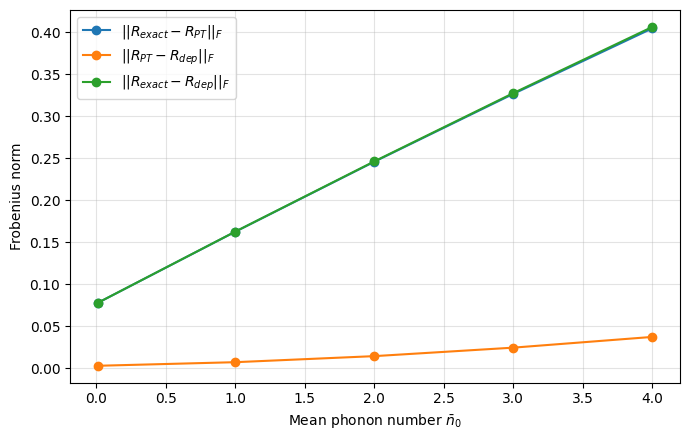

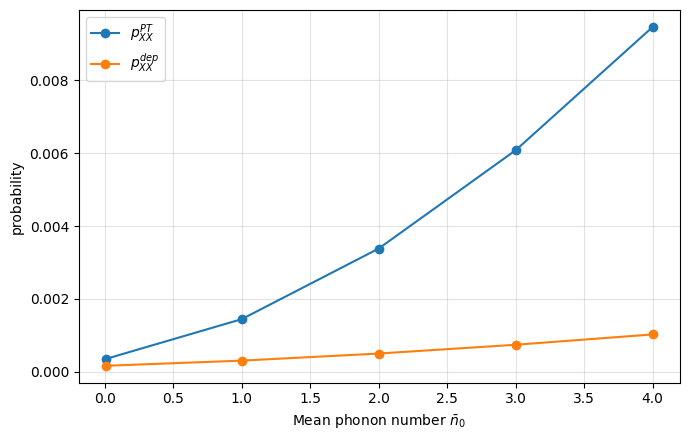

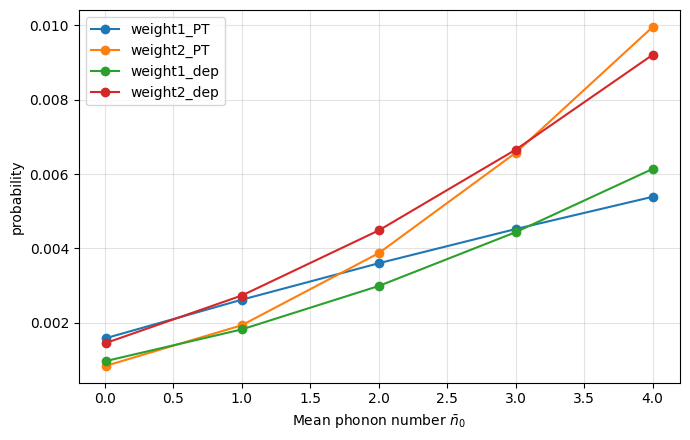

In [24]:
# exact / Pauli-twirled / depolarizing error channel comparison
import importlib
import ms_gate_functions as mg

mg = importlib.reload(mg)

depolarizing_comparison = mg.compare_error_channel_to_depolarizing(
    error_result,
    output_dir="depolarizing_comparison",
    show_summary=True,
)

depolarizing_parameter_summary_df = depolarizing_comparison["depolarizing_parameter_summary_df"]
channel_approximation_distance_summary_df = depolarizing_comparison["channel_approximation_distance_summary_df"]
pauli_distribution_vs_depolarizing_summary_df = depolarizing_comparison["pauli_distribution_vs_depolarizing_summary_df"]
top_pauli_vs_depolarizing_df = depolarizing_comparison["top_pauli_vs_depolarizing_df"]

depolarizing_parameter_summary_df, channel_approximation_distance_summary_df, pauli_distribution_vs_depolarizing_summary_df, top_pauli_vs_depolarizing_df
